In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os
os.makedirs("figs", exist_ok=True)
matplotlib.rcParams.update({'font.size': 11})

base = pd.read_csv("results/baseline.csv")
deg  = pd.read_csv("results/degradation.csv")
cs   = pd.read_csv("results/degradation_csonly.csv")
div  = pd.read_csv("results/divergence.csv")

MODEL_SHORT = {
    "intfloat/e5-base-v2":           "e5-base-v2",
    "BAAI/bge-base-en-v1.5":         "bge-base-en",
    "intfloat/multilingual-e5-base": "mE5-base",
    "BAAI/bge-m3":                   "bge-m3",
}
deg["model_s"]  = deg["model"].map(MODEL_SHORT)
base["model_s"] = base["model"].map(MODEL_SHORT)
cs["model_s"]   = cs["model"].map(MODEL_SHORT)
print("Loaded. Baseline rows:", len(base), "| Degradation rows:", len(deg))

Loaded. Baseline rows: 8 | Degradation rows: 16


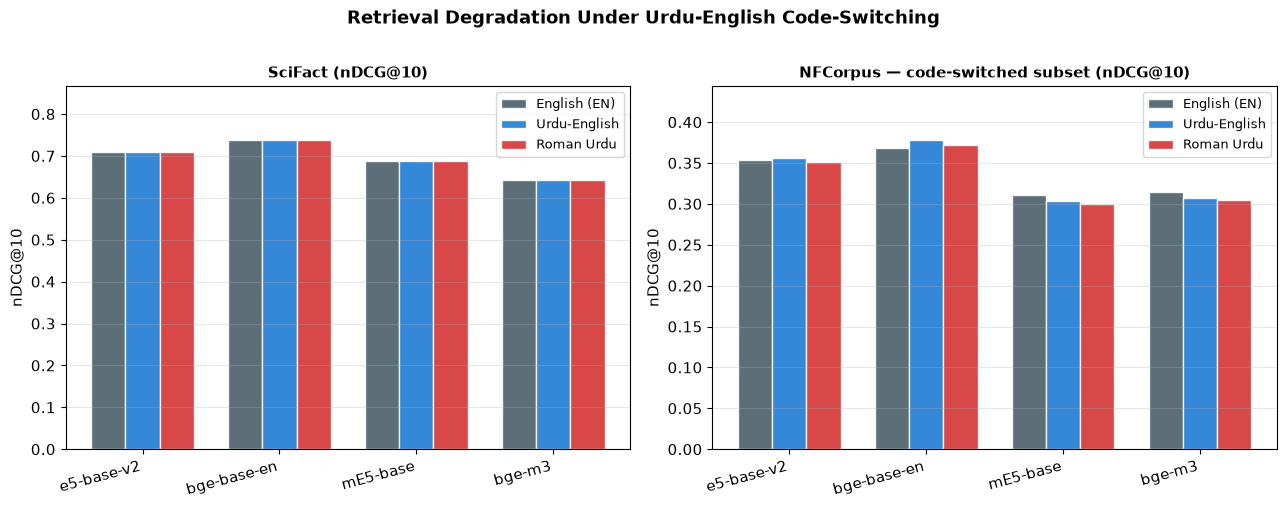

Saved -> figs/fig1_degradation.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
datasets  = ["scifact", "nfcorpus"]
titles    = ["SciFact (nDCG@10)", "NFCorpus — code-switched subset (nDCG@10)"]
colors    = {"EN": "#455A64", "ur_en": "#1976D2", "roman": "#D32F2F"}
labels    = {"EN": "English (EN)", "ur_en": "Urdu-English", "roman": "Roman Urdu"}

for ax, ds, title in zip(axes, datasets, titles):
    models = list(MODEL_SHORT.values())
    x = np.arange(len(models))
    w = 0.25

    for j, (cond, src) in enumerate([
        ("EN",    base[base.dataset == ds]),
        ("ur_en", cs[(cs.dataset == ds) & (cs.condition == "ur_en")]),
        ("roman", cs[(cs.dataset == ds) & (cs.condition == "roman")]),
    ]):
        vals = []
        for m in models:
            row = src[src.model_s == m]
            col = "EN_subset" if cond != "EN" else "nDCG@10"
            vals.append(float(row[col].values[0]) if len(row) else 0)
        bars = ax.bar(x + (j - 1) * w, vals, w, label=labels[cond],
                        color=colors[cond], alpha=0.88, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("nDCG@10")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Retrieval Degradation Under Urdu-English Code-Switching", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figs/fig1_degradation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> figs/fig1_degradation.png")

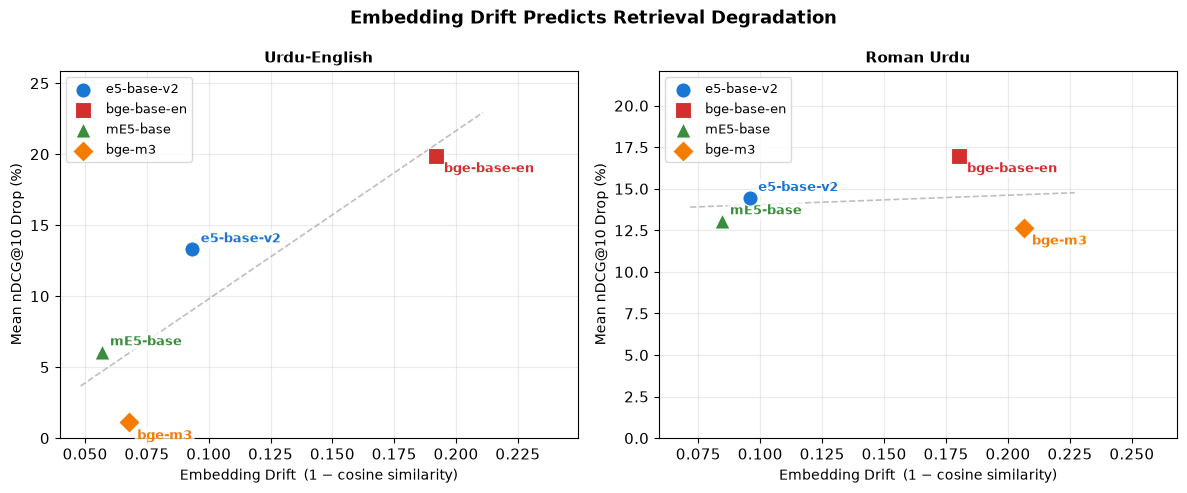

Saved -> figs/fig2_drift_vs_drop.png


In [7]:
# mapping: full name (in cs) -> short name (in div)
FULL_TO_SHORT = {
    "intfloat/e5-base-v2":           "e5-base-v2",
    "BAAI/bge-base-en-v1.5":         "bge-base-en-v1.5",
    "intfloat/multilingual-e5-base": "multilingual-e5-base",
    "BAAI/bge-m3":                   "bge-m3",
}
DISPLAY = {
    "e5-base-v2":           "e5-base-v2",
    "bge-base-en-v1.5":     "bge-base-en",
    "multilingual-e5-base": "mE5-base",
    "bge-m3":               "bge-m3",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
conditions = [("ur_en", "drift_UR", "Urdu-English"), ("roman", "drift_ROM", "Roman Urdu")]
markers      = ["o", "s", "^", "D"]
model_colors = ["#1976D2", "#D32F2F", "#388E3C", "#F57C00"]

label_offsets = {
    "e5-base-v2":           ( 6,  5),
    "bge-base-en-v1.5":     ( 6, -12),
    "multilingual-e5-base": ( 6,  5),
    "bge-m3":               ( 6, -12),
}

for ax, (cond, drift_col, cond_label) in zip(axes, conditions):
    all_x, all_y = [], []
    for i, (mfull, mshort) in enumerate(FULL_TO_SHORT.items()):
        d_row = div[div.model == mshort]
        rows  = cs[(cs.model == mfull) & (cs.condition == cond)]
        if len(d_row) == 0 or len(rows) == 0:
            print(f"MISSING: {mshort} / {cond}"); continue
        drift = float(d_row[drift_col].values[0])
        drop  = float(rows["drop_%"].mean())
        all_x.append(drift); all_y.append(drop)
        disp = DISPLAY[mshort]
        ax.scatter(drift, drop, s=120, marker=markers[i],
                   color=model_colors[i], label=disp,
                   zorder=4, edgecolors="white", linewidths=0.8)
        ox, oy = label_offsets.get(mshort, (6, 5))
        ax.annotate(disp, (drift, drop),
                    textcoords="offset points", xytext=(ox, oy),
                    fontsize=9, fontweight="bold", color=model_colors[i],
                    bbox=dict(boxstyle="round,pad=0.2", fc="white",
                              alpha=0.75, ec="none"))

    if len(all_x) > 1:
        z  = np.polyfit(all_x, all_y, 1)
        p  = np.poly1d(z)
        xs = np.linspace(min(all_x)*0.85, max(all_x)*1.1, 50)
        ax.plot(xs, p(xs), "--", color="gray", alpha=0.5, linewidth=1.2)

    ax.set_xlabel("Embedding Drift  (1 − cosine similarity)", fontsize=10)
    ax.set_ylabel("Mean nDCG@10 Drop (%)", fontsize=10)
    ax.set_title(cond_label, fontweight="bold", fontsize=11)
    ax.legend(fontsize=9, loc="upper left", framealpha=0.85, edgecolor="lightgray")
    ax.grid(alpha=0.25)
    if all_x:
        ax.set_xlim(min(all_x)*0.7,  max(all_x)*1.3)
        ax.set_ylim(0,               max(all_y)*1.3)

plt.suptitle("Embedding Drift Predicts Retrieval Degradation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figs/fig2_drift_vs_drop.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> figs/fig2_drift_vs_drop.png")

In [6]:
print("div models:", div["model"].tolist())
print("cs models:", cs["model"].unique().tolist())

div models: ['e5-base-v2', 'bge-base-en-v1.5', 'multilingual-e5-base', 'bge-m3']
cs models: ['intfloat/e5-base-v2', 'BAAI/bge-base-en-v1.5', 'intfloat/multilingual-e5-base', 'BAAI/bge-m3']


In [4]:
print("="*70)
print("TABLE 1 — Baseline EN Retrieval (nDCG@10)")
print("="*70)
t1 = base.pivot_table(index="model_s", columns="dataset", values="nDCG@10")
print(t1.round(4).to_string())

print("\n" + "="*70)
print("TABLE 2 — Code-Switched Degradation (nDCG@10 | drop%)")
print("          on genuinely code-switched queries only")
print("="*70)
for ds in ["scifact", "nfcorpus"]:
    print(f"\n--- {ds} ---")
    sub = cs[cs.dataset == ds][["model_s","condition","EN_subset","CS","drop_%"]]
    print(sub.to_string(index=False))

print("\n" + "="*70)
print("TABLE 3 — Embedding Drift (1 − cosine similarity to EN)")
print("="*70)
print(div[["model","drift_UR","drift_ROM"]].to_string(index=False))

TABLE 1 — Baseline EN Retrieval (nDCG@10)
dataset      nfcorpus  scifact
model_s                       
bge-base-en    0.3681   0.7376
bge-m3         0.3141   0.6437
e5-base-v2     0.3534   0.7105
mE5-base       0.3113   0.6887

TABLE 2 — Code-Switched Degradation (nDCG@10 | drop%)
          on genuinely code-switched queries only

--- scifact ---
    model_s condition  EN_subset     CS  drop_%
 e5-base-v2     ur_en     0.7105 0.6498     8.5
bge-base-en     ur_en     0.7376 0.5963    19.2
   mE5-base     ur_en     0.6887 0.6623     3.8
     bge-m3     ur_en     0.6437 0.6422     0.2
 e5-base-v2     roman     0.7105 0.6209    12.6
bge-base-en     roman     0.7376 0.6251    15.3
   mE5-base     roman     0.6887 0.6143    10.8
     bge-m3     roman     0.6437 0.5584    13.2

--- nfcorpus ---
    model_s condition  EN_subset     CS  drop_%
 e5-base-v2     ur_en     0.3562 0.2916    18.1
bge-base-en     ur_en     0.3779 0.2999    20.6
   mE5-base     ur_en     0.3038 0.2786     8.3
     bge